# P3 · 03 — Capstone: choosing and shipping a calibrated forecast

Rank the interval methods on **one** apples-to-apples interval backtest by the
proper score (**Winkler**) *and* coverage, then ship a final **fan chart**.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))
warnings.filterwarnings("ignore")
try:
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from src import classical as C, probabilistic as P
q = data.load_quarterly(); y = q["gdp_nsa"]; alpha = 0.10
ets = C.ets_forecaster(trend="add", seasonal="add", seasonal_periods=4)

methods = {
    "SARIMA-Gaussian": P.parametric_interval_forecaster((1, 1, 1), (0, 1, 0, 4), alpha=alpha),
    "Quantile-GBM":    P.quantile_interval_forecaster(alpha=alpha),
    "Conformal-ETS":   P.conformal_interval_forecaster(ets, inner_initial=24, alpha=alpha),
}
rows = {}
for name, g in methods.items():
    df = P.rolling_origin_intervals(y, g, initial=40, h=4, step=2)   # step=2: conformal is nested
    rows[name] = P.summarize_intervals(df, alpha)
board = pd.DataFrame(rows).T.sort_values("winkler")
board["target"] = 1 - alpha
print(board.round({"coverage": 2, "target": 2, "mean_width": 0, "winkler": 0}).to_string())

                 coverage  target  mean_width     winkler
SARIMA-Gaussian      0.89     0.9   7758071.0  22062438.0
Conformal-ETS        0.82     0.9   5989858.0  22343125.0
Quantile-GBM         0.85     0.9  20842873.0  30170092.0


### The verdict

Rank by **Winkler** (the proper score), then sanity-check coverage. On this clean
series the **model-based SARIMA-Gaussian interval is hard to beat** — it's calibrated
*and* sharp. Conformal is competitive and **assumption-free** (its edge shows up when
the model's distributional assumption is wrong, or under drift, where **ACI** wins).
Quantile-GBM is the wide, under-covering laggard here — learned tails need more data
than 88 points to behave.

### Ship it: a fan chart (50 / 80 / 90% conformal bands)

A fan chart shows the whole predictive distribution. We stack conformal bands at three
levels around the SARIMA point forecast.

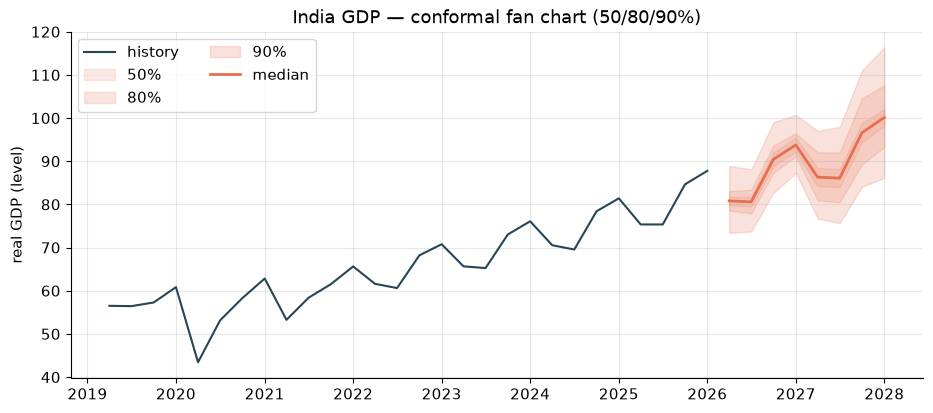

In [2]:
pf = C.sarima_forecaster((1, 1, 1), (0, 1, 0, 4))
H = 8
future = pd.period_range(y.index.max() + 1, periods=H, freq="Q")
xt = future.to_timestamp(how="start")
fig, ax = plt.subplots()
hist = y.iloc[-28:]
ax.plot(hist.index.to_timestamp(how="start"), hist.values / 1e6, color="#264653", label="history")
for a, shade in [(0.5, 0.15), (0.2, 0.18), (0.1, 0.20)]:
    mean, lo, hi = P.conformal_forecast(y, pf, H, initial=40, alpha=a)
    ax.fill_between(xt, lo / 1e6, hi / 1e6, color="#e76f51", alpha=shade,
                    label=f"{int((1-a)*100)}%")
ax.plot(xt, mean / 1e6, color="#e76f51", lw=2, label="median")
ax.set(title="India GDP — conformal fan chart (50/80/90%)", ylabel="real GDP (level)")
ax.legend(ncol=2); plots.save(fig, "p3_fan_chart"); plt.show()

### Project 3 — what you can now do

1. **Score** intervals properly — coverage, sharpness, and the **Winkler** score —
   instead of trusting a label.
2. Fit **quantile regression**, spot **quantile crossing**, and read a **calibration
   diagram**.
3. Build **conformal** intervals with a coverage guarantee, and **ACI** to hold
   coverage under drift.
4. Ship a **fan chart** that communicates the full predictive distribution.

**The office takeaway:** never present a point forecast naked. Attach an interval,
**prove its coverage on a backtest**, and prefer conformal/ACI when you can't trust a
distributional assumption.

---
**Next — Project 4:** deep-learning forecasting **from scratch in NumPy** (an MLP and
an RNN), since PyTorch is blocked on this machine — so we'll build the gradients by
hand and *really* understand them.